In [1]:
import uproot
import matplotlib.pyplot as plt
import pandas as pd
import tqdm
import numpy as np
import os
import glob
import awkward as ak
import boost_histogram as bh
import mplhep
from matplotlib.colors import LogNorm
# !pip install pyarrow
# !pip install "pyarrow<21" --break-system-packages

In [2]:
runs_F222 = [7733, 8712]
runs_F223 = [8713, 9188]

runs_F231 = [10555, 11470]
runs_F232 = [11470, 11703]

runs_F241 = [14399, 15026]
runs_tungsten = [15030, 15594]
runs_F242 = [15652, 15820]
runs_caloNu = [15821, 16924]
runs_F243 = [16928, 17230]

runs_2022 = [8025, 9188]
runs_2023 = [10604, 11703]
runs_2024_preCaloNu = [14399, 15821]
runs_2024_CaloNu = [15821, 16924]
runs_2024_afterCaloNu = [16928, 17230]

In [41]:
def get_cutflow_and_yields_for_run_range(files, run_start=None, run_end=None, mass=1.1):
    cutflow_dict = {}
    run_yields = {}

    total_lumi = 0
    for fpath in tqdm.tqdm(files):

        run = int(os.path.basename(fpath).split("/")[-1].split(".")[0])
        # if run not in good_runs: continue
        
        
        if run_start is not None and run_start > run:
            continue
        if run_end is not None and run > run_end:
            continue

        with uproot.open(fpath) as f:
            tree = f["cutflow"]
            lumi = f["meta"].arrays(library="pd")["lumi"][0]
            df = tree.arrays(library="pd")

            run = int(os.path.basename(fpath).split("/")[-1].split(".")[0])
            # if run not in good_runs: continue


            if "initial" not in cutflow_dict:
                cutflow_dict["initial"] = {"all": 0, "passed": 0}
                
            cutflow_dict["initial"]["all"] += df["all"].max()
            cutflow_dict["initial"]["passed"] += df["passed"].max()
            cutflow_dict["initial"]["efficiency"] = 1
            cutflow_dict["initial"]["cumulative_efficiency"] = 1


            
            total_lumi += lumi[0] / 1000 # /pb -> /fb
            for idx, row in df.iterrows():
                cut = row["cut_name"]
                all = row["all"]
                passed = row["passed"]

                if cut not in cutflow_dict:
                    cutflow_dict[cut] = {"all": 0, "passed": 0}

                cutflow_dict[cut]["all"] += all
                cutflow_dict[cut]["passed"] += passed
                cutflow_dict[cut]["efficiency"] = cutflow_dict[cut]["passed"] / cutflow_dict[cut]["all"] if cutflow_dict[cut]["all"] > 0 else 0
                cutflow_dict[cut]["cumulative_efficiency"] = cutflow_dict[cut]["passed"] / cutflow_dict[list(cutflow_dict.keys())[0]]["all"] if cutflow_dict[list(cutflow_dict.keys())[0]]["all"] > 0 else 0
                cutflow_dict[cut]["efficiency_error"] = np.sqrt(cutflow_dict[cut]["efficiency"] * (1 - cutflow_dict[cut]["efficiency"]) / cutflow_dict[cut]["all"]) if cutflow_dict[cut]["all"] > 0 else 0


                final_yield = np.amin(df["passed"])
                run_yields[int(run)] = final_yield

    if total_lumi <= 0:
        total_lumi = 10_000

    print(f"Total lumi for runs {run_start} to {run_end}: {total_lumi:.2f} fb^-1")

    cutflow = pd.DataFrame.from_dict(cutflow_dict, orient="index")
    cutflow["rate [events/fb/tonne]"] = cutflow["passed"] / (total_lumi * mass) if total_lumi > 0 else 0
    cutflow["rate_error [events/fb/tonne]"] = np.sqrt(cutflow["passed"]) / (total_lumi * mass) if total_lumi > 0 else 0
    cutflow = cutflow.sort_values(by='passed', ascending=False)
            
    return cutflow, run_yields

In [42]:
noCaloNu_cutflow_df, noCaloNu_run_yields = get_cutflow_and_yields_for_run_range(files = ["build/200093.root", "build/200094.root", "build/200100.root",], mass=1.1)

100%|██████████| 3/3 [00:00<00:00, 62.44it/s]

Total lumi for runs None to None: 10000.00 fb^-1


In [ ]:
withCaloNu_cutflow_df, withCaloNu_un_yields = get_cutflow_and_yields_for_run_range(files = ["build/200139.root", "build/200140.root", "build/200146.root",], mass=0.68)

100%|██████████| 3/3 [00:00<00:00, 65.88it/s]

Total lumi for runs None to None: 10000.00 fb^-1


In [44]:
display(noCaloNu_cutflow_df)

,all,passed,efficiency,cumulative_efficiency,efficiency_error,rate [events/fb/tonne],rate_error [events/fb/tonne]
initial,1450841,1450841,1.000000,1.000000,NaN,131.894636,0.109501
Remove CaloNu PMT region (truth),1450841,1450841,1.000000,1.000000,0.000000,131.894636,0.109501
CC events only,1450841,1100511,0.758533,0.758533,0.000355,100.046455,0.095368
nu_mu only,1100511,918140,0.834285,0.632833,0.000354,83.467273,0.087109
In Faser Nu Box or Lead Block,918140,358654,0.390631,0.247204,0.000509,32.604909,0.054443
Truth dec r < 100 mm,358654,173518,0.483803,0.119598,0.000834,15.774364,0.037869
Truth pz > 100 GeV,173518,160243,0.923495,0.110448,0.000638,14.567545,0.036391
VetoNu0 reduced charge < 30 pC,160243,145902,0.910505,0.100564,0.000713,13.263818,0.034725
VetoNu1 reduced charge < 30 pC,145902,139183,0.953949,0.095933,0.000549,12.653000,0.033916
Veto20 and Veto21 charge > 40 pC,139183,138142,0.992521,0.095215,0.000231,12.558364,0.033789


In [45]:
display(withCaloNu_cutflow_df)

,all,passed,efficiency,cumulative_efficiency,efficiency_error,rate [events/fb/tonne],rate_error [events/fb/tonne]
initial,1234895,1232337,1.000000,1.000000,NaN,181.226029,0.163251
Remove CaloNu PMT region (truth),1234895,1232337,0.997929,0.997929,0.000041,181.226029,0.163251
CC events only,1232337,933845,0.757784,0.756214,0.000386,137.330147,0.142111
nu_mu only,933845,778117,0.833240,0.630108,0.000386,114.428971,0.129722
In Faser Nu Box or Lead Block,778117,197115,0.253323,0.159621,0.000493,28.987500,0.065291
Truth dec r < 100 mm,197115,95200,0.482967,0.077092,0.001126,14.000000,0.045374
Truth pz > 100 GeV,95200,87910,0.923424,0.071188,0.000862,12.927941,0.043602
VetoNu0 reduced charge < 30 pC,87910,81023,0.921659,0.065611,0.000906,11.915147,0.041860
VetoNu1 reduced charge < 30 pC,81023,78442,0.968145,0.063521,0.000617,11.535588,0.041187
Veto20 and Veto21 charge > 40 pC,78442,78345,0.998763,0.063443,0.000125,11.521324,0.041162


In [50]:
def plot_cutflow_comparison(noCaloNu_cutflow_df, withCaloNu_cutflow_df):

    fig, ax = plt.subplots(figsize=(10, 6), nrows=2, ncols=1, sharex=True)
    ax[0].bar(noCaloNu_cutflow_df.index, noCaloNu_cutflow_df["rate [events/fb/tonne]"], label="No caloNu", alpha=0.7)
    ax[0].bar(withCaloNu_cutflow_df.index, withCaloNu_cutflow_df["rate [events/fb/tonne]"], label="With caloNu", alpha=0.7)
    ax[0].set_yscale("log")
    ax[0].set_ylabel("Rate [events/fb/tonne]")
    ax[0].set_title("Cutflow Comparison: No caloNu vs With caloNu")
    ax[0].legend()
    ax[1].set_xticklabels(noCaloNu_cutflow_df.index, rotation=45, ha="right")

    ratio = withCaloNu_cutflow_df["rate [events/fb/tonne]"] / noCaloNu_cutflow_df["rate [events/fb/tonne]"]
    ratio_error = np.sqrt((withCaloNu_cutflow_df["rate_error [events/fb/tonne]"] / noCaloNu_cutflow_df["rate [events/fb/tonne]"])**2 + (withCaloNu_cutflow_df["rate [events/fb/tonne]"] * noCaloNu_cutflow_df["rate_error [events/fb/tonne]"] / noCaloNu_cutflow_df["rate [events/fb/tonne]"]**2)**2)
    ax[1].errorbar(noCaloNu_cutflow_df.index, ratio, yerr=ratio_error, color="gray", alpha=0.7, capsize=5, linestyle='None', marker='o')
    # ax[1].bar(noCaloNu_cutflow_df.index, ratio, color="gray", alpha=0.7)
    # ax[1].set_ylabel("Ratio (With caloNu / No caloNu)")
    # ax[1].set_xlabel("Cut Name")
    ax[1].set_ylabel("Ratio \n (With caloNu / No caloNu)")
    ax[1].axhline(1, color="red", linestyle="--")
    plt.tight_layout()


/tmp/ipykernel_2000755/3879132205.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[1].set_xticklabels(noCaloNu_cutflow_df.index, rotation=45, ha="right")


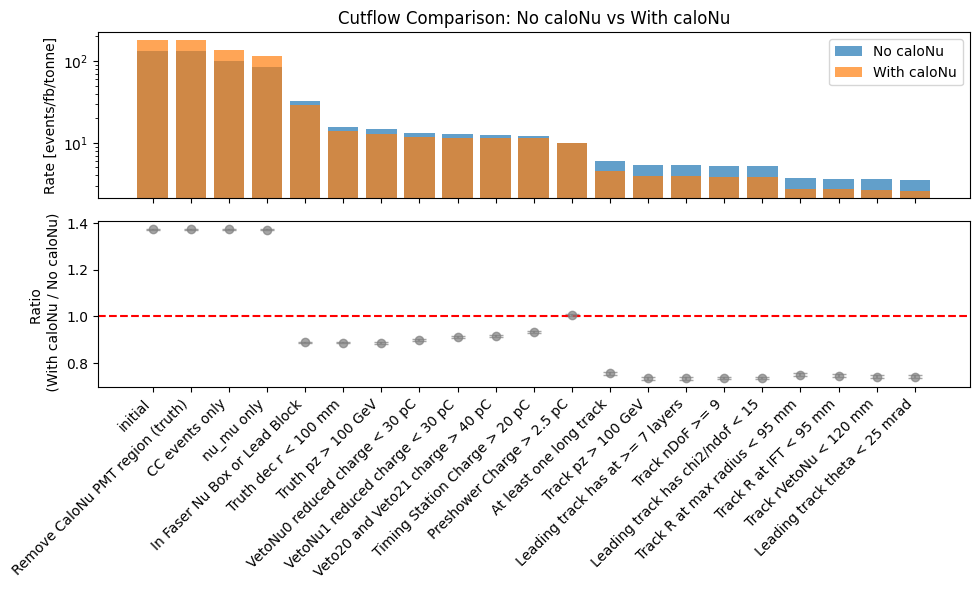

In [51]:
plot_cutflow_comparison(noCaloNu_cutflow_df, withCaloNu_cutflow_df)

100%|██████████| 1/1 [00:00<00:00, 43.23it/s]


Total lumi for runs None to None: 10000.00 fb^-1


100%|██████████| 1/1 [00:00<00:00, 60.57it/s]
/tmp/ipykernel_2000755/3879132205.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[1].set_xticklabels(noCaloNu_cutflow_df.index, rotation=45, ha="right")


Total lumi for runs None to None: 10000.00 fb^-1


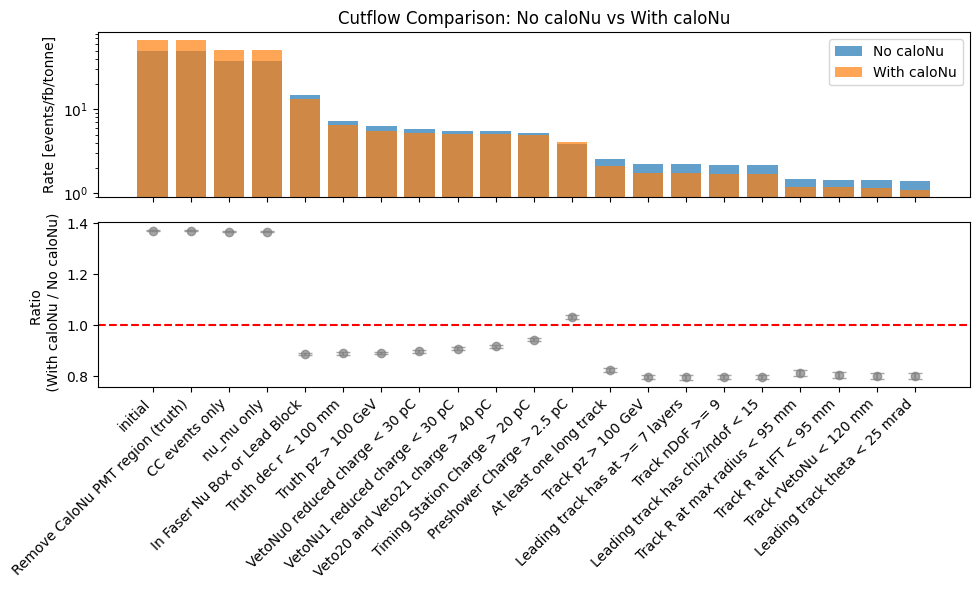

In [52]:
noCaloNu_cutflow_df, noCaloNu_run_yields = get_cutflow_and_yields_for_run_range(files = ["build/200093.root"], mass=1.1)
withCaloNu_cutflow_df, withCaloNu_run_yields = get_cutflow_and_yields_for_run_range(files = ["build/200139.root"], mass=0.68)
plot_cutflow_comparison(noCaloNu_cutflow_df, withCaloNu_cutflow_df)

100%|██████████| 1/1 [00:00<00:00, 39.71it/s]


Total lumi for runs None to None: 10000.00 fb^-1


100%|██████████| 1/1 [00:00<00:00, 50.16it/s]
/tmp/ipykernel_2000755/3879132205.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[1].set_xticklabels(noCaloNu_cutflow_df.index, rotation=45, ha="right")


Total lumi for runs None to None: 10000.00 fb^-1


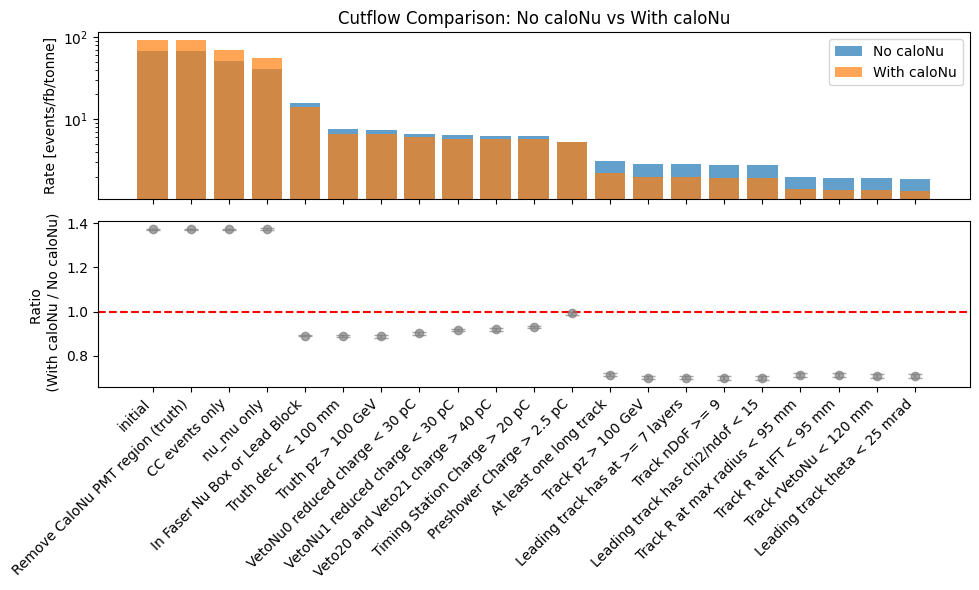

In [53]:
noCaloNu_cutflow_df, noCaloNu_run_yields = get_cutflow_and_yields_for_run_range(files = ["build/200094.root"], mass=1.1)
withCaloNu_cutflow_df, withCaloNu_run_yields = get_cutflow_and_yields_for_run_range(files = ["build/200140.root"], mass=0.68)
plot_cutflow_comparison(noCaloNu_cutflow_df, withCaloNu_cutflow_df)

100%|██████████| 1/1 [00:00<00:00, 43.80it/s]


Total lumi for runs None to None: 10000.00 fb^-1


100%|██████████| 1/1 [00:00<00:00, 61.42it/s]
/tmp/ipykernel_2000755/3879132205.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[1].set_xticklabels(noCaloNu_cutflow_df.index, rotation=45, ha="right")


Total lumi for runs None to None: 10000.00 fb^-1


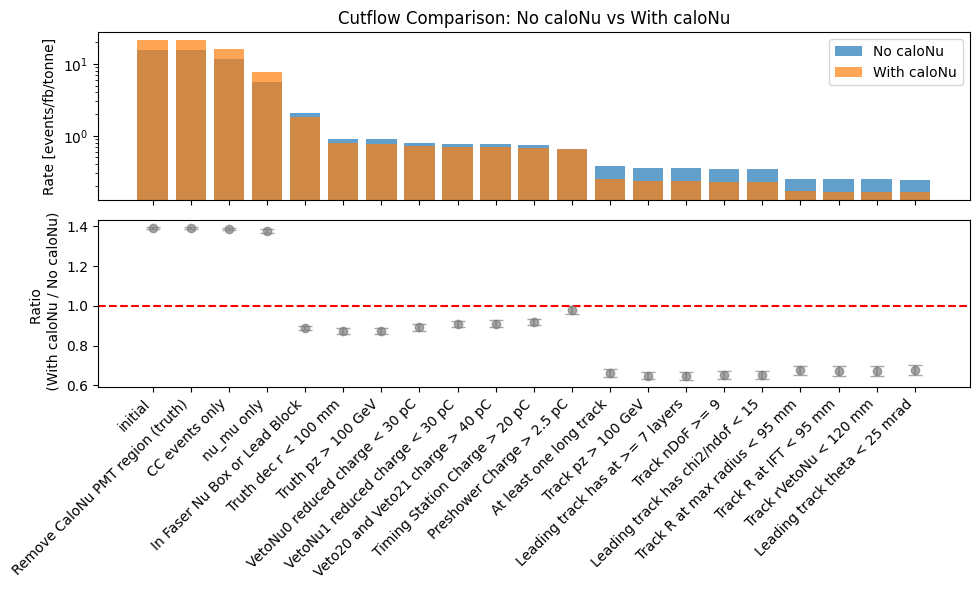

In [54]:
noCaloNu_cutflow_df, noCaloNu_run_yields = get_cutflow_and_yields_for_run_range(files = ["build/200100.root"], mass=1.1)
withCaloNu_cutflow_df, withCaloNu_run_yields = get_cutflow_and_yields_for_run_range(files = ["build/200146.root"], mass=0.68)
plot_cutflow_comparison(noCaloNu_cutflow_df, withCaloNu_cutflow_df)

In [55]:
data_noCaloNu = uproot.concatenate(["build/200093.root:nt", "build/200094.root:nt", "build/200100.root:nt"], filter_name=["crossingAngle"])
data_withCaloNu = uproot.concatenate(["build/200139.root:nt", "build/200140.root:nt", "build/200146.root:nt"], filter_name=["crossingAngle"])

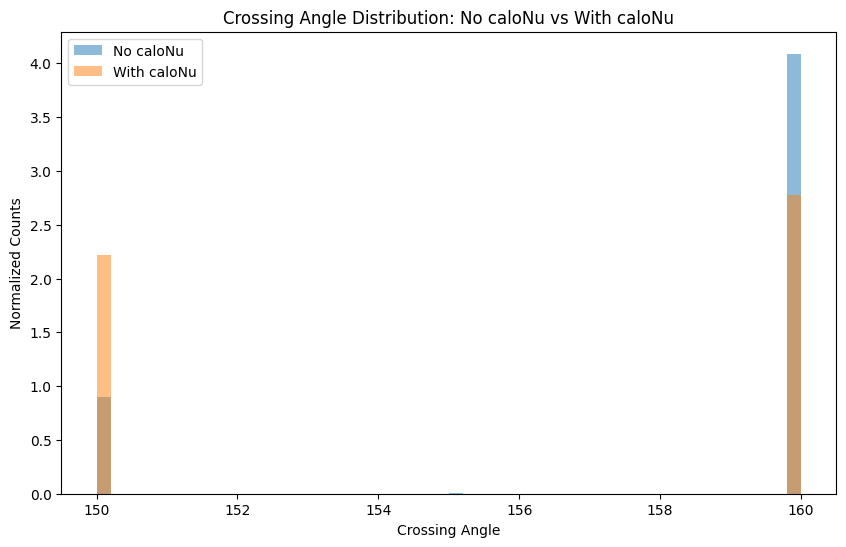

In [59]:
fig, ax = plt.subplots(figsize=(10, 6))
# bins = np.linspace(-0.5, 0.5, 50)
bins=50
ax.hist(data_noCaloNu["crossingAngle"], bins=bins, alpha=0.5, label="No caloNu", density=True)
ax.hist(data_withCaloNu["crossingAngle"], bins=bins, alpha=0.5, label="With caloNu", density=True)
ax.set_xlabel("Crossing Angle")
ax.set_ylabel("Normalized Counts")
ax.set_title("Crossing Angle Distribution: No caloNu vs With caloNu")
ax.legend()

In [1]:
print(set(data_noCaloNu["crossingAngle"]))
print(set(data_withCaloNu["crossingAngle"]))

NameError: name 'data_noCaloNu' is not defined